In [1]:
import pandas as pd

deg = pd.read_csv("../data/processed/de_transcriptome.csv").set_index("Gene")
dep = pd.read_csv("../data/processed/de_proteome.csv").set_index("gene")
sig_rna = set(deg.index)
sig_prot = set(dep.index)

overlap = sig_rna & sig_prot
print(len(overlap))

10011


In [12]:
merged = deg.merge(
    dep,
    left_index=True,
    right_index=True,
    suffixes=("_rna","_prot")
)

corr = merged["log2FC_rna"].corr(merged["log2FC_prot"])
print(f"Pearson correlation = {corr:.3f}")
print(f"Squared Pearson correlation = {corr**2:.3f}")
merged

Pearson correlation = 0.728
Squared Pearson correlation = 0.530


,log2FC_rna,pvalue_rna,adjustedpvalue_rna,-log(adjustedp)_rna,log2FC_prot,pvalue_prot,adjustedpvalue_prot,-log(adjustedp)_prot
Gene,,,,,,,,
A1BG,-0.051346,7.039758e-01,7.649690e-01,0.116356,1.751663,1.740332e-19,1.649829e-18,17.782561
A2M,0.895503,2.751120e-10,1.613700e-09,8.792177,1.446368,2.631714e-14,1.480730e-13,12.829524
AAAS,1.170456,2.530039e-05,7.293219e-05,4.137081,0.603250,5.753307e-08,1.502036e-07,6.823320
AACS,-1.200968,2.777619e-10,1.627681e-09,8.788431,-0.747064,8.155613e-09,2.376589e-08,7.624046
AADAT,-0.470732,1.837089e-06,6.219132e-06,5.206270,-1.181237,7.377722e-08,1.893361e-07,6.722767
...,...,...,...,...,...,...,...,...
ZXDC,0.261725,8.692046e-05,2.314533e-04,3.635537,-0.051378,8.127155e-01,8.287182e-01,0.081593
ZYG11B,-0.771744,6.547534e-12,4.963860e-11,10.304181,-0.642655,5.650706e-12,2.446680e-11,10.611423
ZYX,1.145736,5.245179e-17,9.734448e-16,15.011689,1.046176,1.121758e-11,4.672422e-11,10.330458


In [3]:
merged.to_csv("../data/processed/differential_gbm_combined.csv")

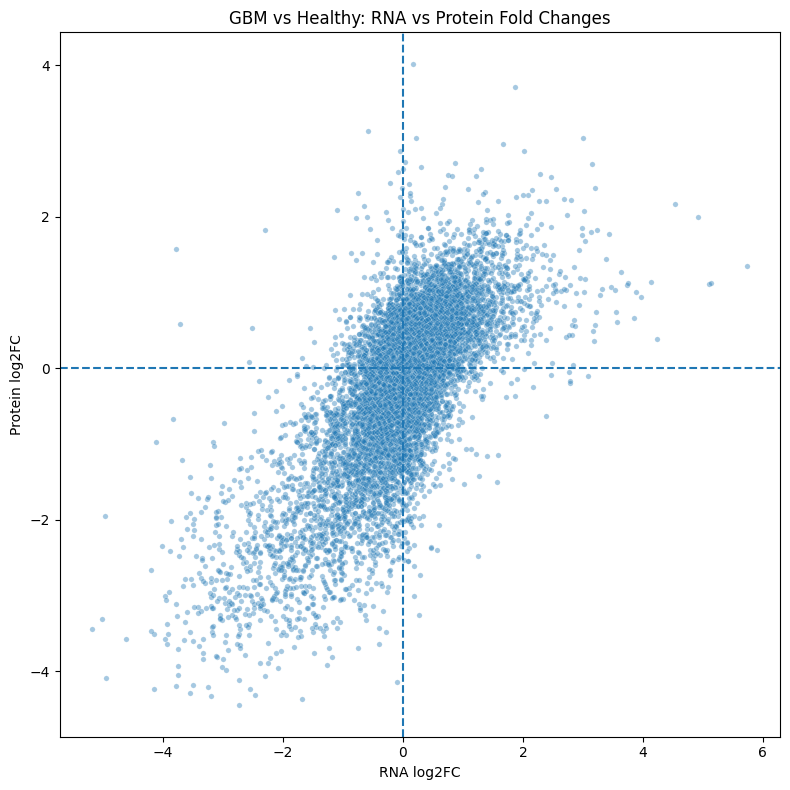

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))

sns.scatterplot(
    data=merged,
    x="log2FC_rna",
    y="log2FC_prot",
    alpha=0.4,
    s=15
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("RNA log2FC")
plt.ylabel("Protein log2FC")
plt.title("GBM vs Healthy: RNA vs Protein Fold Changes")

plt.tight_layout()
plt.show()



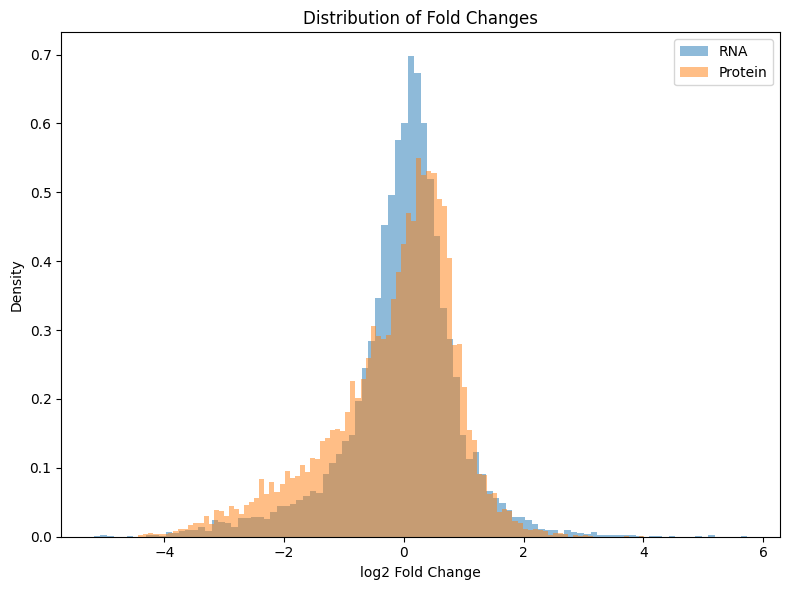

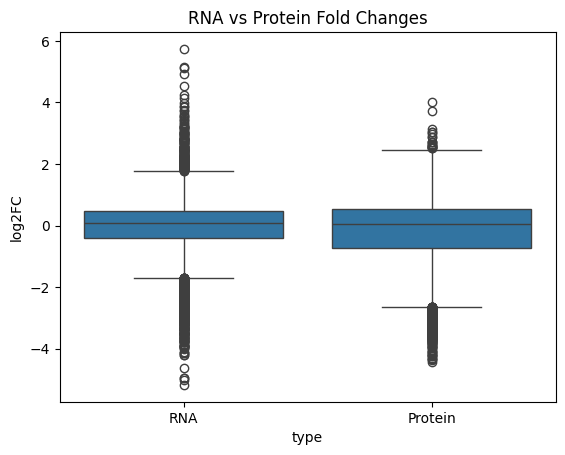

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(
    merged["log2FC_rna"],
    bins=100,
    alpha=0.5,
    density=True,
    label="RNA"
)

plt.hist(
    merged["log2FC_prot"],
    bins=100,
    alpha=0.5,
    density=True,
    label="Protein"
)

plt.xlabel("log2 Fold Change")
plt.ylabel("Density")
plt.title("Distribution of Fold Changes")
plt.legend()

plt.tight_layout()
plt.show()


plot_df = pd.DataFrame({
    "value": pd.concat([
        merged["log2FC_rna"],
        merged["log2FC_prot"]
    ]),
    "type": (
        ["RNA"] * len(merged) +
        ["Protein"] * len(merged)
    )
})

sns.boxplot(data=plot_df, x="type", y="value")
plt.ylabel("log2FC")
plt.title("RNA vs Protein Fold Changes")
plt.show()

# Proteins that are the expressed the same "sign"

In [13]:

merged2 = merged.copy()
merged2 = merged2[merged["log2FC_rna"] * merged["log2FC_prot"] > 0]

corr2 = merged2["log2FC_rna"].corr(merged2["log2FC_prot"])
print(f"Pearson correlation = {corr2:.3f}")
print(f"Squared Pearson correlation = {corr2**2:.3f}")

merged2

Pearson correlation = 0.820
Squared Pearson correlation = 0.672


,log2FC_rna,pvalue_rna,adjustedpvalue_rna,-log(adjustedp)_rna,log2FC_prot,pvalue_prot,adjustedpvalue_prot,-log(adjustedp)_prot
Gene,,,,,,,,
A2M,0.895503,2.751120e-10,1.613700e-09,8.792177,1.446368,2.631714e-14,1.480730e-13,12.829524
AAAS,1.170456,2.530039e-05,7.293219e-05,4.137081,0.603250,5.753307e-08,1.502036e-07,6.823320
AACS,-1.200968,2.777619e-10,1.627681e-09,8.788431,-0.747064,8.155613e-09,2.376589e-08,7.624046
AADAT,-0.470732,1.837089e-06,6.219132e-06,5.206270,-1.181237,7.377722e-08,1.893361e-07,6.722767
AAED1,1.235063,1.386718e-09,7.361896e-09,8.133010,0.870320,4.539880e-03,6.213755e-03,2.206646
...,...,...,...,...,...,...,...,...
ZW10,0.055366,2.488346e-01,3.258164e-01,0.487027,0.170689,1.517266e-03,2.203603e-03,2.656867
ZWILCH,0.343858,7.097133e-04,1.642846e-03,2.784403,0.940229,7.961461e-07,1.781020e-06,5.749331
ZYG11B,-0.771744,6.547534e-12,4.963860e-11,10.304181,-0.642655,5.650706e-12,2.446680e-11,10.611423


In [8]:
merged2.to_csv("../data/processed/samesign.csv")

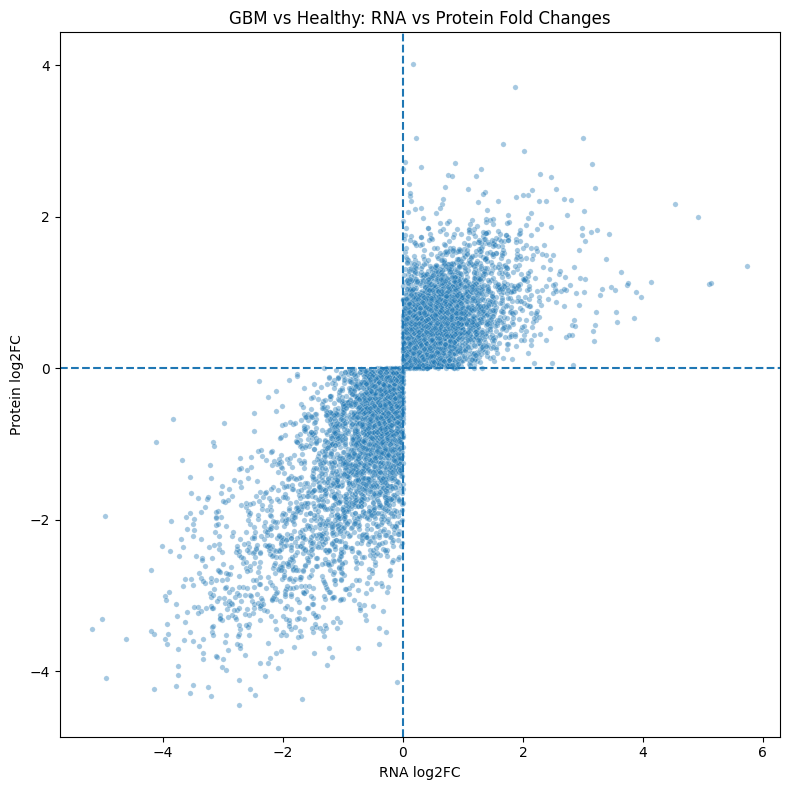

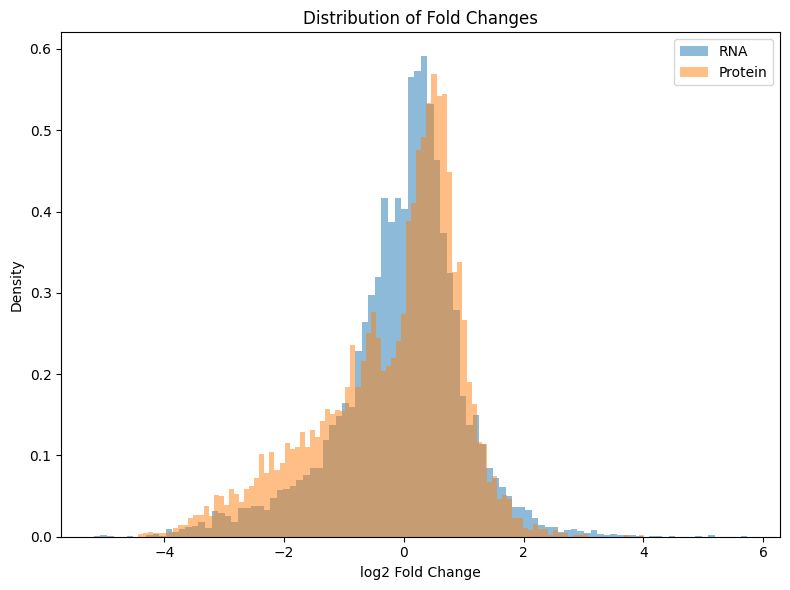

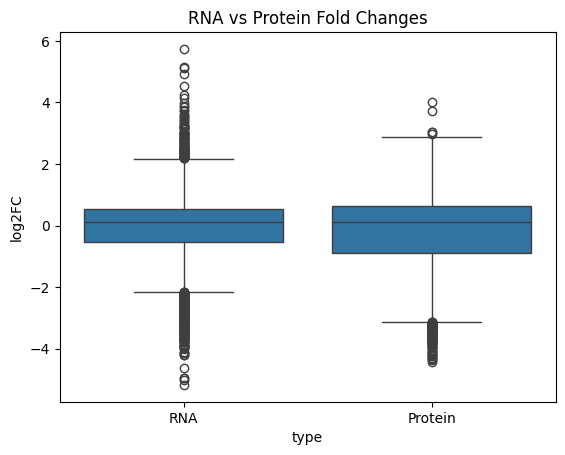

In [11]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,8))

sns.scatterplot(
    data=merged2,
    x="log2FC_rna",
    y="log2FC_prot",
    alpha=0.4,
    s=15
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")

plt.xlabel("RNA log2FC")
plt.ylabel("Protein log2FC")
plt.title("GBM vs Healthy: RNA vs Protein Fold Changes")

plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(
    merged2["log2FC_rna"],
    bins=100,
    alpha=0.5,
    density=True,
    label="RNA"
)

plt.hist(
    merged2["log2FC_prot"],
    bins=100,
    alpha=0.5,
    density=True,
    label="Protein"
)

plt.xlabel("log2 Fold Change")
plt.ylabel("Density")
plt.title("Distribution of Fold Changes")
plt.legend()

plt.tight_layout()
plt.show()


plot_df = pd.DataFrame({
    "value": pd.concat([
        merged2["log2FC_rna"],
        merged2["log2FC_prot"]
    ]),
    "type": (
        ["RNA"] * len(merged2) +
        ["Protein"] * len(merged2)
    )
})

sns.boxplot(data=plot_df, x="type", y="value")
plt.ylabel("log2FC")
plt.title("RNA vs Protein Fold Changes")
plt.show()

